
# BAC NSI — Sujet RLE (corrigé)

Ce notebook regroupe :
- Q1 : justification sur la longueur du codage RLE ;
- Q2 : fonction `decodage_rle` + tests ;
- Q3 : encodage→décodage d'images avec l'encodeur **naïf** (problème des runs >255) ;
- Q4 : encodeur **sécurisé** (runs découpés en blocs ≤255) + vérifications.

> Les deux images utilisées sont celles fournies : `bac_nsi_32.png` et `bac_nsi_256.png`.



## Q1 — La liste RLE est-elle toujours plus courte ?

Non. Le codage **RLE** 
encode les *runs* (séries consécutives) sous la forme `[compte, valeur]`.  
Si les valeurs ne se répètent pas (ou très peu), on double la taille : par exemple `[0, 1] → [1, 0, 1, 1]` (2 valeurs → 4 éléments).  
Elle n'est plus courte que si suffisamment de répétitions existent.



## Préliminaires — utilitaires d'E/S (octets & images)

On fournit quelques fonctions utilitaires pour lire/écrire des octets et des images en niveaux de gris, afin de reproduire les tests des questions suivantes.


In [1]:

from PIL import Image
from pathlib import Path
from typing import List, Tuple
from IPython.display import display

def enregistrer_octets(nom_fichier: str, liste_octets: List[int]) -> None:
    """Écrit la liste d'entiers (0..255) en binaire dans nom_fichier."""
    with open(nom_fichier, 'wb') as f:
        f.write(bytes([max(0, min(255, b)) for b in liste_octets]))

def charger_octets(nom_fichier: str) -> List[int]:
    """Lit un fichier binaire et renvoie la liste des octets (0..255)."""
    with open(nom_fichier, 'rb') as f:
        return list(f.read())

def enregistrer_image(nom_image: str, largeur: int, liste_niveaux: List[int]) -> None:
    """Sauve une image 8 bits (L) à partir d'une liste de niveaux de gris (row-major)."""
    hauteur = len(liste_niveaux) // largeur
    im = Image.frombytes('L', (largeur, hauteur), bytes(liste_niveaux))
    im.save(nom_image)

def charger_image(nom_image: str) -> Tuple[int, List[int]]:
    """Charge une image en niveaux de gris (L). Renvoie (largeur, pixels)."""
    im = Image.open(nom_image).convert('L')
    return im.width, list(im.tobytes())

# Petits helpers d'affichage
def show_gray(path: str, title: str = None, scale: int = 1):
    im = Image.open(path).convert('L')
    if scale != 1:
        im = im.resize((im.width*scale, im.height*scale), resample=Image.NEAREST)
    if title:
        print(title)
    display(im)



## Q2 — Fonction `decodage_rle`

On décode simplement la séquence `[c1, v1, c2, v2, ...]` en répétant `vi` exactement `ci` fois.


In [2]:

def decodage_rle(liste_rle):
    """Renvoie la liste d'octets obtenue à partir de la liste RLE [c1,v1,c2,v2,...]."""
    out = []
    for i in range(0, len(liste_rle), 2):
        count = liste_rle[i]
        value = liste_rle[i+1]
        out.extend([value] * count)
    return out

# Encodeur « naïf » (tel que dans l'énoncé), utile pour les tests
def codage_rle_naive(liste_octets):
    liste_rle = []
    i = 0
    while i < len(liste_octets):
        c = liste_octets[i]
        k = 1
        while i+k < len(liste_octets) and liste_octets[i+k] == c:
            k += 1
        liste_rle.append(k)
        liste_rle.append(c)
        i += k
    return liste_rle

# Tests de cohérence de l'énoncé
assert codage_rle_naive([255, 255, 0, 255, 255, 255]) == [2, 255, 1, 0, 3, 255]
assert decodage_rle([2, 255, 1, 0, 3, 255]) == [255, 255, 0, 255, 255, 255]
print("Q2: tests OK")


Q2: tests OK



## Q3 — Encodage→décodage d'images avec l'encodeur **naïf**

On applique l'encodeur naïf à deux images (`bac_nsi_32.png`, `bac_nsi_256.png`), on sauvegarde le RLE, on recharge, on décode et on sauvegarde l'image décodée.

> Problème attendu : l'encodeur naïf peut produire un **compte > 255**. Or, lors de l'écriture « octets », les comptes sont **bornés à 255**, ce qui tronque les longues séries et casse le décodage sur certaines images.


[{'file_len': 854,
  'image': 'bac_nsi_32.png',
  'out_image': 'bac_nsi_32.png.naive.dec.png',
  'pixels_decoded': 1024,
  'pixels_in': 1024,
  'rle_len': 854},
 {'file_len': 9008,
  'image': 'bac_nsi_256.png',
  'out_image': 'bac_nsi_256.png.naive.dec.png',
  'pixels_decoded': 51494,
  'pixels_in': 65536,
  'rle_len': 9008}]
Décodée (naïf) — bac_nsi_32.png


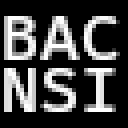

Décodée (naïf) — bac_nsi_256.png


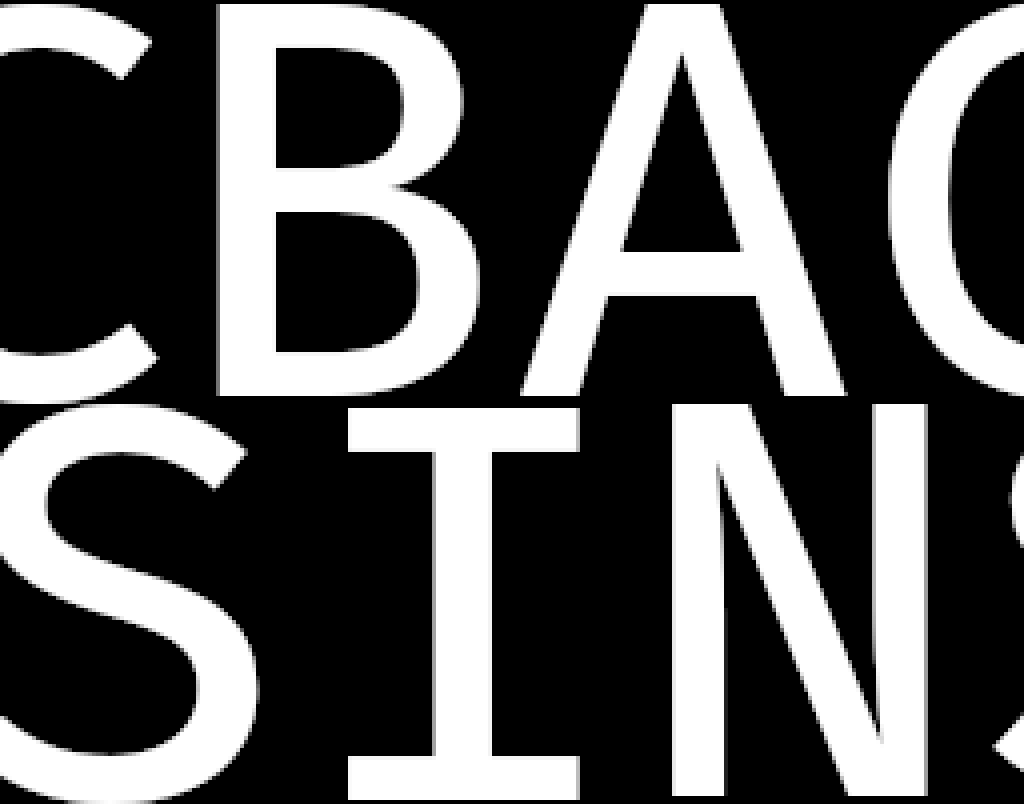

In [3]:

from pprint import pprint

def encoder_decoder_image_naive(nom_image: str):
    w, pixels = charger_image(nom_image)
    rle = codage_rle_naive(pixels)
    rle_path = nom_image + ".naive.rle"
    out_path = nom_image + ".naive.dec.png"
    enregistrer_octets(rle_path, rle)        # ⚠️ tronque à 0..255
    rle_bytes = charger_octets(rle_path)
    decoded = decodage_rle(rle_bytes)
    enregistrer_image(out_path, w, decoded)
    return {
        "image": nom_image,
        "pixels_in": len(pixels),
        "rle_len": len(rle),
        "file_len": len(rle_bytes),
        "pixels_decoded": len(decoded),
        "out_image": out_path
    }

imgs = ["bac_nsi_32.png", "bac_nsi_256.png"]
naive_results = [encoder_decoder_image_naive(p) for p in imgs]
pprint(naive_results)

# Affichage des images décodées (x4 pour mieux voir)
for res in naive_results:
    show_gray(res["out_image"], title=f"Décodée (naïf) — {Path(res['image']).name}", scale=4)



## Q4 — Encoder des séries >255 (version **sécurisée**)

**Idée :** découper toute série de longueur `k` en blocs de taille ≤ 255.

Ex. `k=300, v=0` → `[255, 0, 45, 0]`.

Le décodage ne change pas : il répète `count` fois la valeur, quel que soit `count`.


In [4]:

def codage_rle_255safe(liste_octets, max_run=255):
    """Encode RLE en découpant les runs en blocs de taille <= 255."""
    res = []
    i = 0
    n = len(liste_octets)
    while i < n:
        v = liste_octets[i]
        k = 1
        while i + k < n and liste_octets[i + k] == v:
            k += 1
        remaining = k
        while remaining > 0:
            take = min(remaining, max_run)
            res.extend([take, v])
            remaining -= take
        i += k
    return res

def decodage_rle_255safe(liste_rle):
    """Le décodage standard suffit déjà."""
    return decodage_rle(liste_rle)

# Tests supplémentaires
assert codage_rle_255safe([0]*300) == [255,0,45,0]
assert decodage_rle_255safe([255,0,45,0]) == [0]*300
print("Q4: encodeur/décodeur sûrs — tests OK")


Q4: encodeur/décodeur sûrs — tests OK


[{'file_len': 854,
  'image': 'bac_nsi_32.png',
  'out_image': 'bac_nsi_32.png.safe.dec.png',
  'pixels_decoded': 1024,
  'pixels_in': 1024,
  'rle_len': 854},
 {'file_len': 9120,
  'image': 'bac_nsi_256.png',
  'out_image': 'bac_nsi_256.png.safe.dec.png',
  'pixels_decoded': 65536,
  'pixels_in': 65536,
  'rle_len': 9120}]
Décodée (sûr) — bac_nsi_32.png


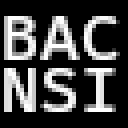

Décodée (sûr) — bac_nsi_256.png


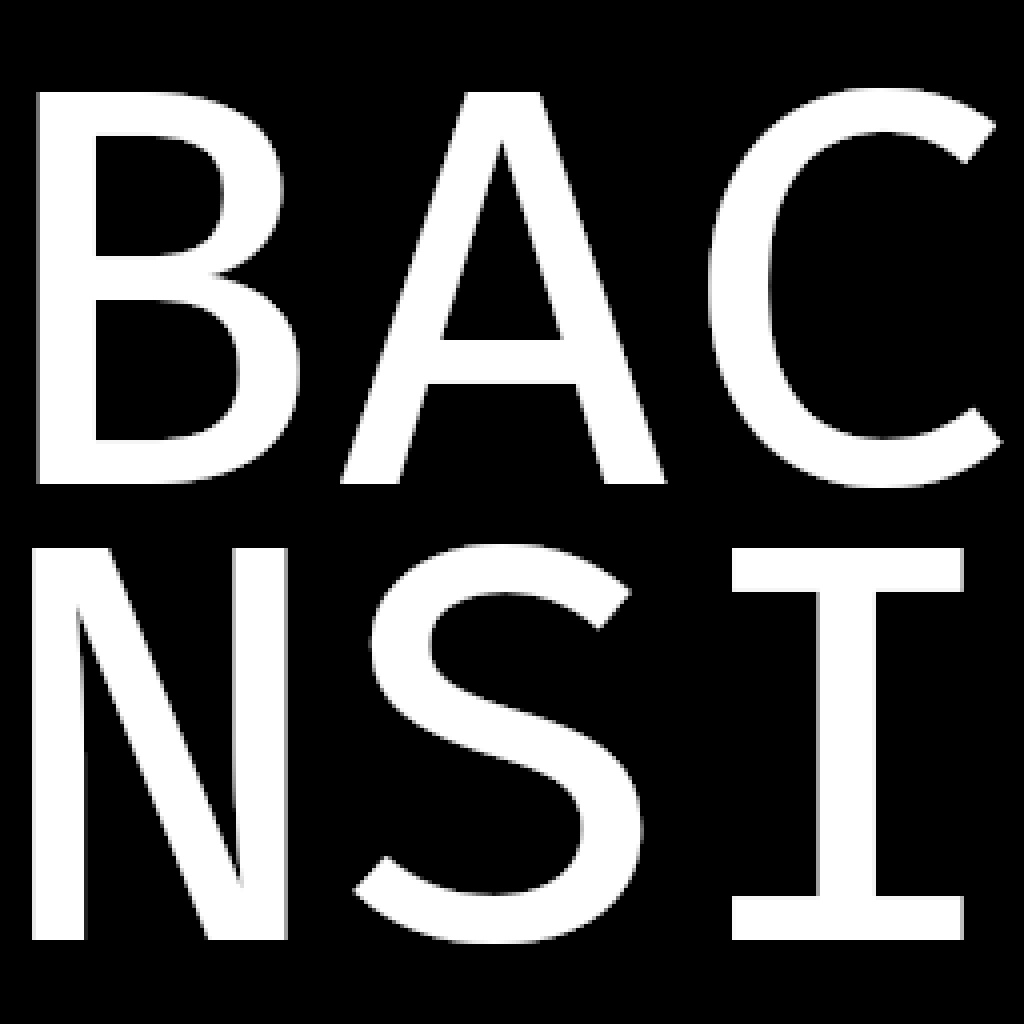

In [5]:

def encoder_decoder_image_safe(nom_image: str):
    w, pixels = charger_image(nom_image)
    rle = codage_rle_255safe(pixels)  # version sûre
    rle_path = nom_image + ".safe.rle"
    out_path = nom_image + ".safe.dec.png"
    enregistrer_octets(rle_path, rle)
    rle_bytes = charger_octets(rle_path)
    decoded = decodage_rle_255safe(rle_bytes)
    enregistrer_image(out_path, w, decoded)
    return {
        "image": nom_image,
        "pixels_in": len(pixels),
        "rle_len": len(rle),
        "file_len": len(rle_bytes),
        "pixels_decoded": len(decoded),
        "out_image": out_path
    }

safe_results = [encoder_decoder_image_safe(p) for p in imgs]
from pprint import pprint
pprint(safe_results)

# Affichage des images décodées (x4)
for res in safe_results:
    show_gray(res["out_image"], title=f"Décodée (sûr) — {Path(res['image']).name}", scale=4)



## Bilan

- L'encodeur naïf fonctionne sur des petites images, mais échoue si un run dépasse 255 (écriture sur un octet).

- La version **sécurisée** découpe les runs et préserve l'intégrité des données pour toutes longueurs.

- Le décodage reste identique (il s'appuie uniquement sur le couple `[compte, valeur]` lu).
